In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [2]:
# read cleaned data
df = pd.read_csv('../data/cleaned/avg_rent_month_cleaned.csv')

In [3]:
df.head()

,Month,Class A Hong Kong,Class A Hong Kong - < 20 transactions,Class A Kowloon,Class A Kowloon - < 20 transactions,Class A New Territories,Class A New Territories - < 20 transactions,Class B Hong Kong,Class B Hong Kong - < 20 transactions,Class B Kowloon,...,Class D Kowloon,Class D Kowloon - < 20 transactions,Class D New Territories,Class D New Territories - < 20 transactions,Class E Hong Kong,Class E Hong Kong - < 20 transactions,Class E Kowloon,Class E Kowloon - < 20 transactions,Class E New Territories,Class E New Territories - < 20 transactions
0,2015-11-01,430,False,327,False,265,False,391,False,316,...,333,False,249,False,465,False,299,True,246,True
1,2015-12-01,433,False,323,False,263,False,379,False,303,...,316,False,254,False,454,False,296,True,248,True
2,2016-01-01,432,False,314,False,255,False,365,False,299,...,341,False,261,False,427,False,341,True,231,True
3,2016-02-01,407,False,308,False,249,False,361,False,288,...,337,False,281,False,435,False,346,True,246,True
4,2016-03-01,396,False,303,False,249,False,353,False,299,...,305,False,261,False,442,False,322,True,229,False


### 1. Load & Preprocess Data

In [5]:
# Convert Month to datetime
df['Month'] = pd.to_datetime(df['Month'])
df = df.sort_values('Month').reset_index(drop=True)

# Add helper columns
df['Year']     = df['Month'].dt.year
df['MonthNum'] = df['Month'].dt.month

# Define classes and regions
classes = ['Class A', 'Class B', 'Class C', 'Class D', 'Class E']
regions = ['Hong Kong', 'Kowloon', 'New Territories']

# Separate rent columns from flag columns
rent_cols = [c for c in df.columns if 'Class' in c and '< 20' not in c]
flag_cols  = [c for c in df.columns if '< 20' in c]

# Convert rent values to numeric (replace "-" with NaN)
df[rent_cols] = df[rent_cols].apply(pd.to_numeric, errors='coerce')

# Summary
print(f"Date range : {df['Month'].min().strftime('%Y-%m')} to {df['Month'].max().strftime('%Y-%m')}")
print(f"Total rows : {len(df)}")
print(f"Rent cols  : {len(rent_cols)}")
print(f"\nMissing values:\n{df[rent_cols].isnull().sum()}")

Date range : 2015-11 to 2025-11
Total rows : 121
Rent cols  : 15

Missing values:
Class A Hong Kong          0
Class A Kowloon            0
Class A New Territories    0
Class B Hong Kong          0
Class B Kowloon            0
Class B New Territories    0
Class C Hong Kong          0
Class C Kowloon            0
Class C New Territories    0
Class D Hong Kong          0
Class D Kowloon            0
Class D New Territories    0
Class E Hong Kong          0
Class E Kowloon            0
Class E New Territories    0
dtype: int64


### 2. Feature Engineering

In [ ]:
# 2.1 Regional average rent (mean across all classes)
for reg in regions:
    cols = [c for c in rent_cols if reg in c]
    df[f'Avg_{reg}'] = df[cols].mean(axis=1)

# 2.2 <20 transaction flag per Class × Region
for c in classes:
    for r in regions:
        fc = f'{c} {r} - < 20 transactions'
        if fc in df.columns:
            df[f'Flag_{c}_{r}'] = df[fc].astype(str).str.strip() == 'True'
        else:
            df[f'Flag_{c}_{r}'] = False

# 2.3 YoY growth (12-month lag)
for reg in regions:
    df[f'YoY_{reg}'] = df[f'Avg_{reg}'].pct_change(12) * 100

# Flag count summary
print("Low-transaction months (<20 deals) per Class × Region:")
for c in classes:
    for r in regions:
        n = df[f'Flag_{c}_{r}'].sum()
        if n > 0:
            print(f"  {c} {r}: {n} months")

Low-transaction months (<20 deals) per Class × Region:
  Class E Kowloon: 119 months
  Class E New Territories: 21 months


### 3. Trend Chart — All Classes × All Regions (with <20 transaction markers)

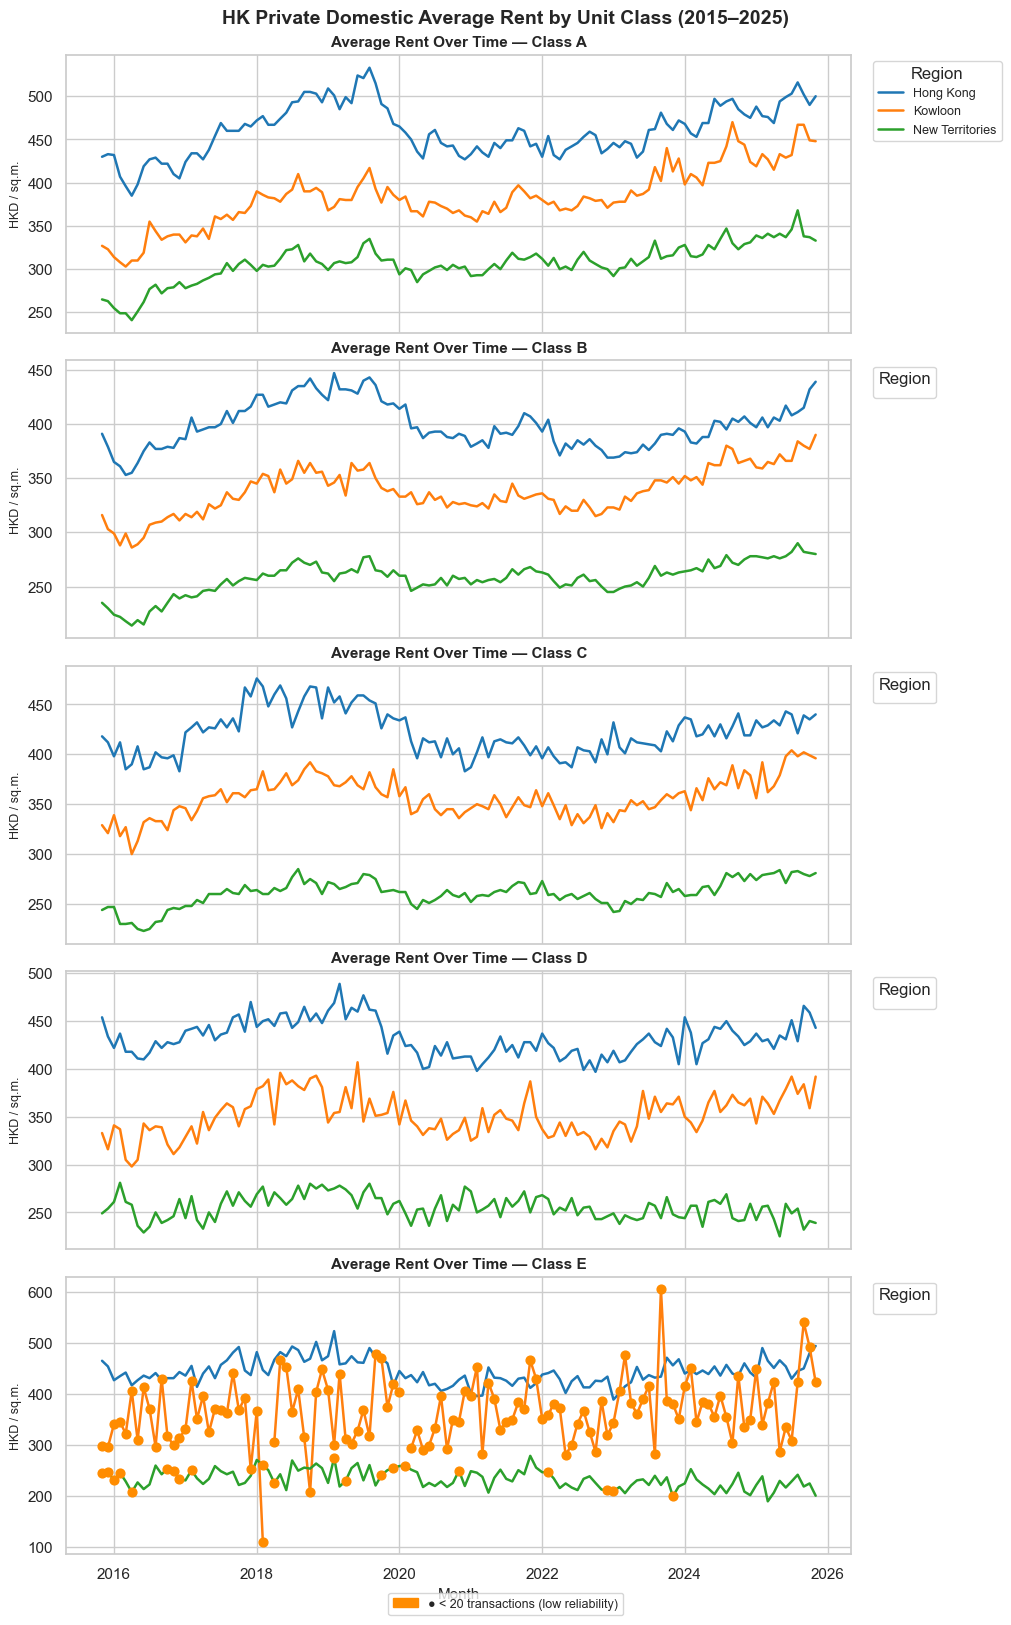

In [ ]:
region_colors = {
    'Hong Kong':       '#1f77b4',
    'Kowloon':         '#ff7f0e',
    'New Territories': '#2ca02c'
}

fig, axes = plt.subplots(len(classes), 1, figsize=(10, 16),
                          sharex=True, constrained_layout=True)
fig.suptitle('HK Private Domestic Average Rent by Unit Class (2015–2025)',
             fontsize=14, fontweight='bold')

for i, c in enumerate(classes):
    ax = axes[i]
    class_cols = [f'{c} {r}' for r in regions if f'{c} {r}' in df.columns]

    for col in class_cols:
        region = col.replace(f'{c} ', '')
        color  = region_colors[region]

        # Main trend line
        ax.plot(df['Month'], df[col],
                color=color, linewidth=1.8,
                label=region if i == 0 else '_nolegend_')

        # Orange dots: months with <20 transactions
        flag_col = f'Flag_{c}_{region}'
        low = df[df[flag_col] == True]
        if not low.empty:
            ax.scatter(low['Month'], low[col],
                       color='darkorange', zorder=5, s=40,
                       label='< 20 transactions' if (i == 0 and region == 'Hong Kong') else '_nolegend_')

    ax.set_title(f'Average Rent Over Time — {c}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('HKD / sq.m.', fontsize=9)
    ax.legend(title='Region', bbox_to_anchor=(1.02, 1),
              loc='upper left', fontsize=9)

axes[-1].set_xlabel('Month', fontsize=11)

# Global legend for orange dot
low_handle = mpatches.Patch(color='darkorange',
                             label='● < 20 transactions (low reliability)')
fig.legend(handles=[low_handle], loc='lower center',
           bbox_to_anchor=(0.5, -0.01), fontsize=9)

plt.show()

### 4. HK Island — All Classes Comparison

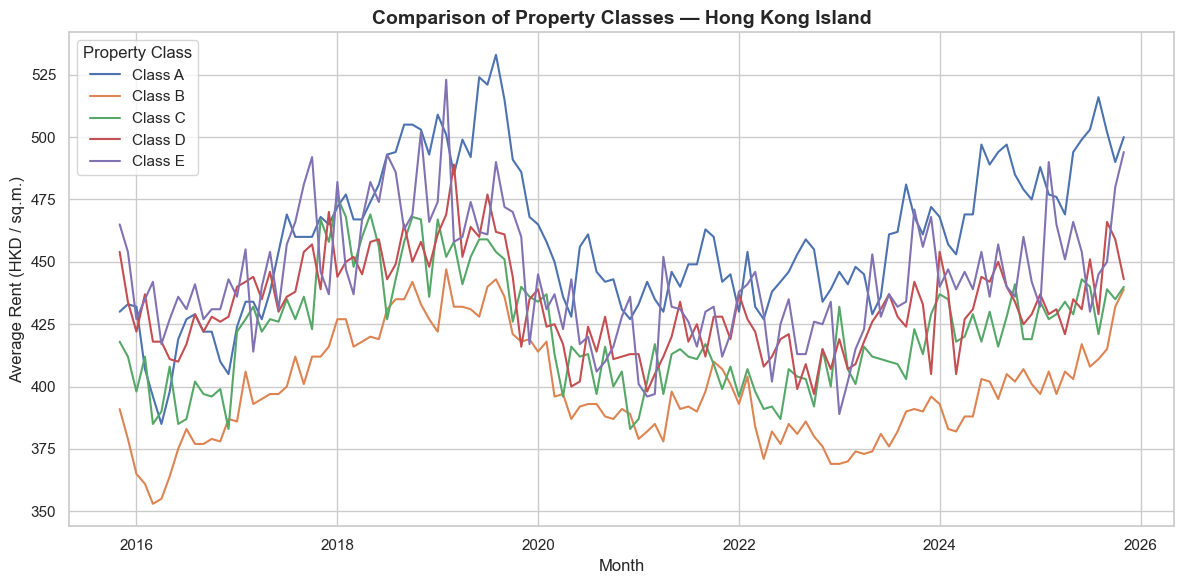

In [ ]:
plt.figure(figsize=(12, 6))

for c in classes:
    col = f'{c} Hong Kong'
    if col in df.columns:
        sns.lineplot(data=df, x='Month', y=col, label=c)

plt.title('Comparison of Property Classes — Hong Kong Island',
          fontsize=14, fontweight='bold')
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Rent (HKD / sq.m.)', fontsize=12)
plt.legend(title='Property Class')
plt.tight_layout()
plt.show()

### 5. Distribution — Histogram + KDE by Region

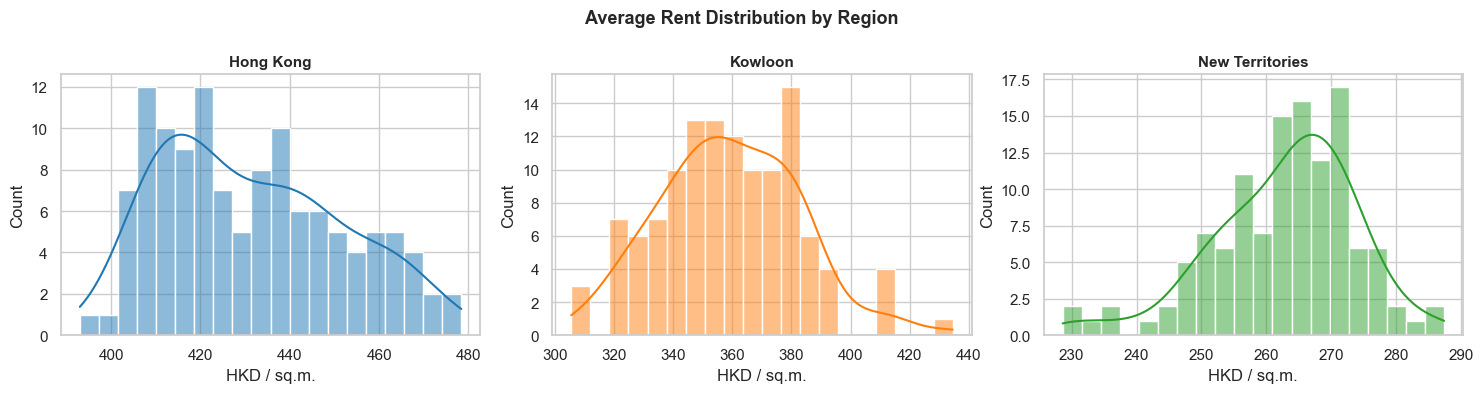

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, reg in enumerate(regions):
    sns.histplot(df[f'Avg_{reg}'].dropna(), bins=20, kde=True,
                 ax=axes[i], color=list(region_colors.values())[i])
    axes[i].set_title(f'{reg}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel('HKD / sq.m.')
    axes[i].set_ylabel('Count')

plt.suptitle('Average Rent Distribution by Region', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 6. YoY Growth — Grouped Bar Chart

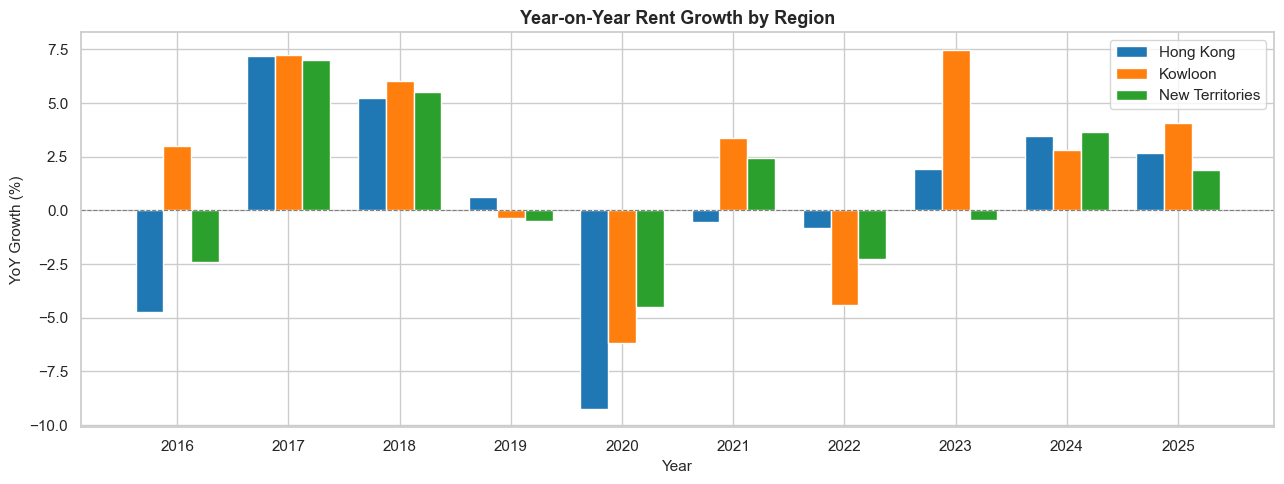

In [ ]:
yearly = df.groupby('Year')[[f'Avg_{r}' for r in regions]].mean()
yoy    = yearly.pct_change() * 100
yoy    = yoy.dropna()

x     = np.arange(len(yoy))
width = 0.25

fig, ax = plt.subplots(figsize=(13, 5))
for j, reg in enumerate(regions):
    bars = ax.bar(x + j * width, yoy[f'Avg_{reg}'].values, width,
                  label=reg, color=list(region_colors.values())[j])

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_xticks(x + width)
ax.set_xticklabels(yoy.index.astype(str))
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('YoY Growth (%)', fontsize=11)
ax.set_title('Year-on-Year Rent Growth by Region',
             fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### 7. Correlation Heatmap

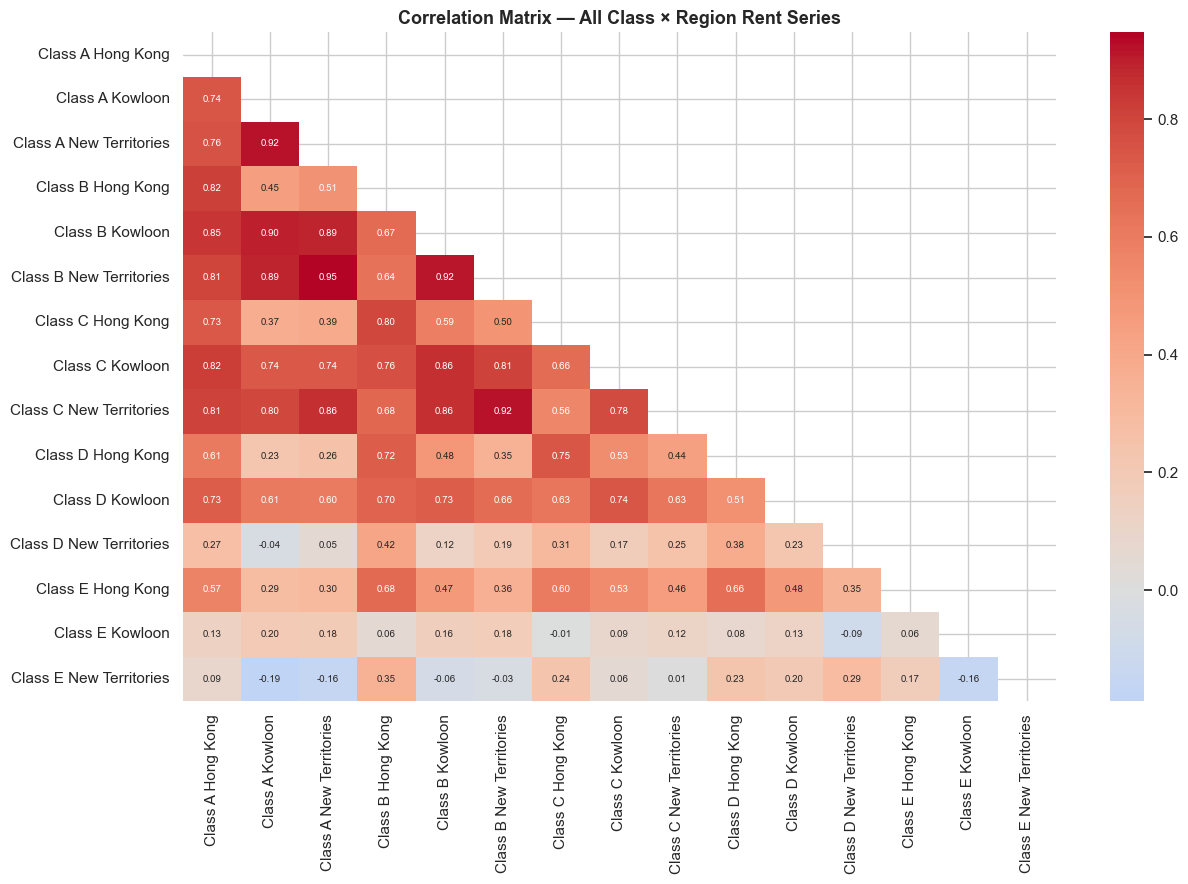

In [ ]:
corr_df = df[rent_cols].corr()
mask    = np.triu(np.ones_like(corr_df, dtype=bool))

fig, ax = plt.subplots(figsize=(13, 9))
sns.heatmap(corr_df, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=ax,
            annot_kws={'size': 7})
ax.set_title('Correlation Matrix — All Class × Region Rent Series',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

plt.close('all')